# Store Sales Forecasting - 02 Supervised Learning Task

This notebook formulates the machine learning problem after the data understanding and preparation step.

The objective is to define clearly:

1. What the model must predict.
2. Which observations are used as training examples.
3. Which features are valid and which must be excluded.
4. How the chronological validation strategy works.
5. Which evaluation metric will be used.
6. A simple baseline model for comparison with the later PyTorch neural network.

## 1. Imports and Settings

This notebook expects that `01_data_understanding_preparation.ipynb` has already been run.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PREPARED_DIR = Path("outputs/prepared_notebook")

TRAIN_PATH = PREPARED_DIR / "train_prepared.csv"
VALIDATION_PATH = PREPARED_DIR / "validation_prepared.csv"
TEST_PATH = PREPARED_DIR / "test_prepared.csv"
SUMMARY_PATH = PREPARED_DIR / "data_summary.json"

## 2. Load Prepared Data

We load the already-prepared files. The train and validation sets both contain the target `Sales`. The test set contains the future rows where the final model will predict `Sales`.

In [2]:
required_files = [TRAIN_PATH, VALIDATION_PATH, TEST_PATH, SUMMARY_PATH]
missing_files = [path for path in required_files if not path.exists()]

if missing_files:
    missing_text = "\n".join(str(path) for path in missing_files)
    raise FileNotFoundError(
        "Prepared files were not found. Run 01_data_understanding_preparation.ipynb first.\n"
        f"Missing files:\n{missing_text}"
    )

train_df = pd.read_csv(TRAIN_PATH, parse_dates=["Date"], low_memory=False)
val_df = pd.read_csv(VALIDATION_PATH, parse_dates=["Date"], low_memory=False)
test_df = pd.read_csv(TEST_PATH, parse_dates=["Date"], low_memory=False)

with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
    data_summary = json.load(f)

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)

train: (51108, 34)
validation: (4200, 34)
test: (3456, 33)


In [3]:
def date_range_text(df):
    return f"{df['Date'].min().date()} to {df['Date'].max().date()}"

print("Train period:", date_range_text(train_df))
print("Validation period:", date_range_text(val_df))
print("Test period:", date_range_text(test_df))

display(train_df.head())

Train period: 2014-01-01 to 2015-06-19
Validation period: 2015-06-20 to 2015-07-31
Test period: 2015-08-01 to 2015-09-17


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,quarter,dayofyear,is_weekend,is_month_start,is_month_end,days_since_start,dow_sin,dow_cos,month_sin,month_cos,competition_open_months,promo2_active
0,47,3,2014-01-01,0,0,0,0,a,1,a,c,270.0,4,2013,1,14,2013,"Jan,Apr,Jul,Oct",2014,1,1,1,1,1,0,1,0,0,4.338837e-01,-0.900969,0.5,0.866025,9,0
1,47,4,2014-01-02,6154,850,1,0,0,1,a,c,270.0,4,2013,1,14,2013,"Jan,Apr,Jul,Oct",2014,1,2,1,1,2,0,0,0,1,-4.338837e-01,-0.900969,0.5,0.866025,9,0
2,47,5,2014-01-03,5305,776,1,0,0,1,a,c,270.0,4,2013,1,14,2013,"Jan,Apr,Jul,Oct",2014,1,3,1,1,3,0,0,0,2,-9.749279e-01,-0.222521,0.5,0.866025,9,0
3,47,6,2014-01-04,5523,825,1,0,0,0,a,c,270.0,4,2013,1,14,2013,"Jan,Apr,Jul,Oct",2014,1,4,1,1,4,1,0,0,3,-7.818315e-01,0.623490,0.5,0.866025,9,0
4,47,7,2014-01-05,0,0,0,0,0,0,a,c,270.0,4,2013,1,14,2013,"Jan,Apr,Jul,Oct",2014,1,5,1,1,5,1,0,0,4,-2.449294e-16,1.000000,0.5,0.866025,9,0


## 3. Supervised Learning Formulation

We formulate the problem as a **supervised regression forecasting task**.

Each row is one supervised example:

`one store` + `one date` + `known store/calendar/promotion information` -> `daily Sales`

The target is continuous, so this is a regression problem rather than a classification problem.

Because the validation dates are after the training dates, validation simulates the real forecasting situation: learning from the past and predicting the future.

In [4]:
target_column = "Sales"
prediction_unit = "store-date pair"
problem_type = "supervised regression forecasting"

task_definition = {
    "problem_type": problem_type,
    "prediction_unit": prediction_unit,
    "target_column": target_column,
    "train_period": date_range_text(train_df),
    "validation_period": date_range_text(val_df),
    "test_period": date_range_text(test_df),
}

task_definition

{'problem_type': 'supervised regression forecasting',
 'prediction_unit': 'store-date pair',
 'target_column': 'Sales',
 'train_period': '2014-01-01 to 2015-06-19',
 'validation_period': '2015-06-20 to 2015-07-31',
 'test_period': '2015-08-01 to 2015-09-17'}

## 4. Valid Features and Excluded Features

A feature is valid only if it is known at prediction time and does not leak the target.

`Customers` is excluded because it is available in `train.csv` but not in `test.csv`. In a real forecast, we do not know future customer counts before predicting future sales.

In [5]:
categorical_features = [
    "Store",
    "DayOfWeek",
    "StateHoliday",
    "StoreType",
    "Assortment",
]

numeric_features = [
    "Open",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "year",
    "month",
    "day",
    "weekofyear",
    "quarter",
    "dayofyear",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "days_since_start",
    "competition_open_months",
    "promo2_active",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

model_features = categorical_features + numeric_features
excluded_features = ["Customers"]

print("Target:", target_column)
print("Number of categorical features:", len(categorical_features))
print("Number of numeric features:", len(numeric_features))
print("Total model features:", len(model_features))
print("Excluded features:", excluded_features)

Target: Sales
Number of categorical features: 5
Number of numeric features: 25
Total model features: 30
Excluded features: ['Customers']


In [6]:
def check_columns_available(df, features, df_name):
    missing = [column for column in features if column not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {df_name}: {missing}")
    print(f"All selected features are available in {df_name}.")


check_columns_available(train_df, model_features + [target_column], "train_df")
check_columns_available(val_df, model_features + [target_column], "val_df")
check_columns_available(test_df, model_features, "test_df")

All selected features are available in train_df.
All selected features are available in val_df.
All selected features are available in test_df.


## 5. Feature Groups

For a school project, it is clearer to reason about feature groups instead of only individual variables. These groups can later be used for ablation experiments, where we train models with and without each group to test whether it improves validation performance.

In [7]:
feature_groups = {
    "store_identity": ["Store"],
    "store_metadata": ["StoreType", "Assortment"],
    "calendar": [
        "DayOfWeek",
        "year",
        "month",
        "day",
        "weekofyear",
        "quarter",
        "dayofyear",
        "is_weekend",
        "is_month_start",
        "is_month_end",
        "days_since_start",
        "dow_sin",
        "dow_cos",
        "month_sin",
        "month_cos",
    ],
    "operations_and_holidays": ["Open", "StateHoliday", "SchoolHoliday"],
    "promotions": ["Promo", "Promo2", "Promo2SinceWeek", "Promo2SinceYear", "promo2_active"],
    "competition": [
        "CompetitionDistance",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "competition_open_months",
    ],
}

feature_group_summary = pd.DataFrame(
    {
        "group": list(feature_groups.keys()),
        "n_features": [len(values) for values in feature_groups.values()],
        "features": [", ".join(values) for values in feature_groups.values()],
    }
)

display(feature_group_summary)

,group,n_features,features
0,store_identity,1,Store
1,store_metadata,2,"StoreType, Assortment"
2,calendar,15,"DayOfWeek, year, month, day, weekofyear, quart..."
3,operations_and_holidays,3,"Open, StateHoliday, SchoolHoliday"
4,promotions,5,"Promo, Promo2, Promo2SinceWeek, Promo2SinceYea..."
5,competition,4,"CompetitionDistance, CompetitionOpenSinceMonth..."


## 6. Target Transformation

Sales values are non-negative and usually skewed. A common regression trick is to train on `log1p(Sales)` instead of raw `Sales`.

`log1p(Sales)` means `log(1 + Sales)`. Later, predictions can be converted back with `expm1`, meaning `exp(prediction) - 1`.

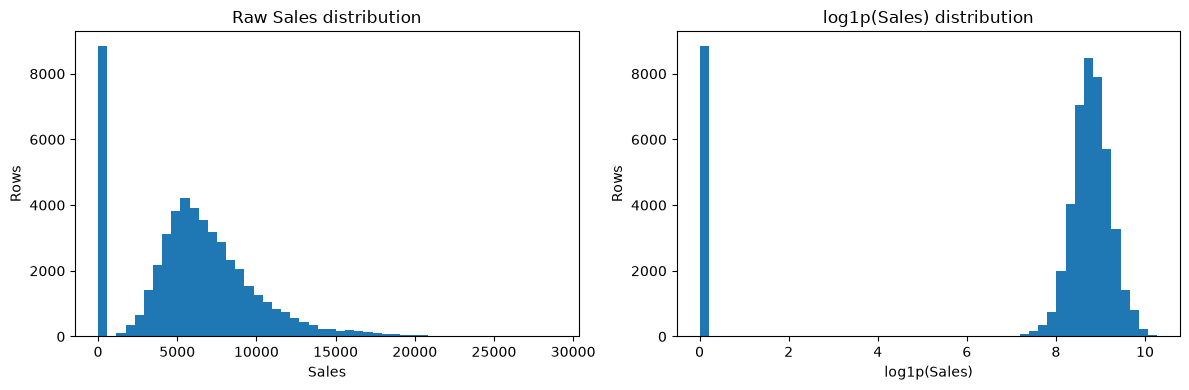

In [8]:
train_df["log_sales"] = np.log1p(train_df[target_column])
val_df["log_sales"] = np.log1p(val_df[target_column])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df[target_column], bins=50)
axes[0].set_title("Raw Sales distribution")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Rows")

axes[1].hist(train_df["log_sales"], bins=50)
axes[1].set_title("log1p(Sales) distribution")
axes[1].set_xlabel("log1p(Sales)")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.show()

## 7. Evaluation Metric

For this sales forecasting task, a useful metric is **RMSPE**: Root Mean Squared Percentage Error.

It measures relative error instead of absolute error, which is helpful because some stores have much higher sales than others.

Rows where actual sales are zero are excluded from RMSPE to avoid division by zero. For closed stores, we can use the business rule `Open == 0 -> predicted Sales = 0`.

In [9]:
def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

## 8. Build X and y Objects

These variables define the supervised learning matrices that will be used in the modeling notebook.

The PyTorch notebook will still need to encode categorical features and scale numeric features, but the conceptual machine learning task is now defined.

In [10]:
X_train = train_df[model_features].copy()
y_train = train_df["log_sales"].copy()

X_val = val_df[model_features].copy()
y_val = val_df["log_sales"].copy()

X_test = test_df[model_features].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)

X_train: (51108, 30)
y_train: (51108,)
X_val: (4200, 30)
y_val: (4200,)
X_test: (3456, 30)


## 9. Simple Baseline Model

Before training a neural network, we create a simple baseline. A good machine learning model should improve over this.

Baseline rule:

- If the store is closed, predict `0`.
- Otherwise, predict the average historical sales for the same `Store` and `DayOfWeek`.
- If that combination is missing, fall back to the average sales for that store.
- If the store is missing, fall back to the global average sales.

In [11]:
open_train = train_df[train_df["Open"] == 1].copy()

global_mean_sales = open_train[target_column].mean()
store_mean_sales = open_train.groupby("Store")[target_column].mean()
store_dow_mean_sales = open_train.groupby(["Store", "DayOfWeek"])[target_column].mean()


def baseline_predict(df):
    predictions = []
    for row in df[["Store", "DayOfWeek", "Open"]].itertuples(index=False):
        if row.Open == 0:
            predictions.append(0.0)
            continue
        
        store_dow_key = (row.Store, row.DayOfWeek)
        if store_dow_key in store_dow_mean_sales.index:
            predictions.append(float(store_dow_mean_sales.loc[store_dow_key]))
        elif row.Store in store_mean_sales.index:
            predictions.append(float(store_mean_sales.loc[row.Store]))
        else:
            predictions.append(float(global_mean_sales))
    return np.array(predictions)


baseline_val_predictions = baseline_predict(val_df)

baseline_results = {
    "validation_rmspe": float(rmspe(val_df[target_column], baseline_val_predictions)),
    "validation_mae": float(mae(val_df[target_column], baseline_val_predictions)),
}

baseline_results

{'validation_rmspe': 0.2572570719130853, 'validation_mae': 1111.7830421413503}

## 10. Baseline Error Visualization

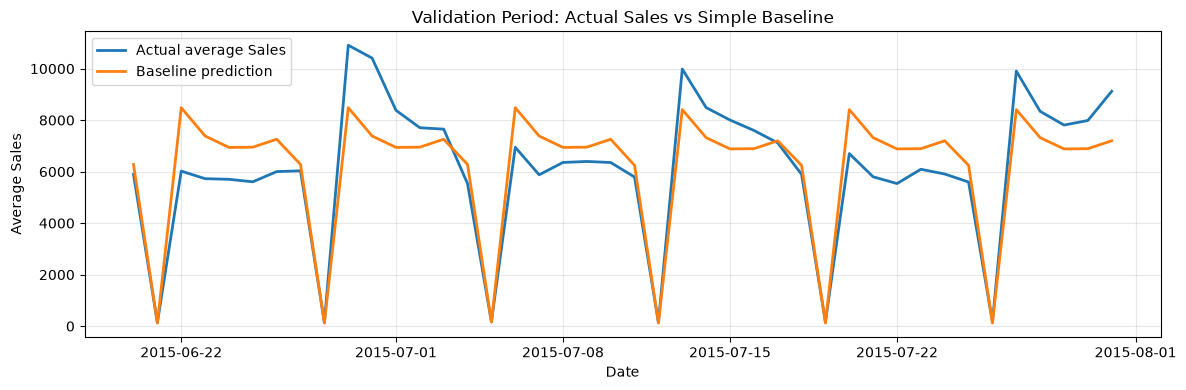

In [12]:
baseline_plot_df = val_df[["Date", "Sales", "Open"]].copy()
baseline_plot_df["baseline_prediction"] = baseline_val_predictions

daily_baseline = (
    baseline_plot_df.groupby("Date", as_index=False)[["Sales", "baseline_prediction"]]
    .mean()
    .sort_values("Date")
)

plt.figure(figsize=(12, 4))
plt.plot(daily_baseline["Date"], daily_baseline["Sales"], label="Actual average Sales", linewidth=2)
plt.plot(daily_baseline["Date"], daily_baseline["baseline_prediction"], label="Baseline prediction", linewidth=2)
plt.title("Validation Period: Actual Sales vs Simple Baseline")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Final Task Definition for Part 03

The next step is to implement a PyTorch neural network for this task.

The model should:

- receive `model_features` as input;
- encode categorical features such as `Store`, `StoreType`, and `Assortment`;
- scale numeric features;
- predict `log1p(Sales)`;
- convert predictions back to sales with `expm1`;
- set predictions to `0` when `Open == 0`;
- evaluate on the chronological validation set using RMSPE and MAE.

In [13]:
part_02_summary = {
    "task_definition": task_definition,
    "target_column": target_column,
    "training_target": "log_sales = log1p(Sales)",
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "model_features": model_features,
    "excluded_features": excluded_features,
    "feature_groups": feature_groups,
    "baseline_results": baseline_results,
}

summary_output_path = PREPARED_DIR / "part_02_supervised_task_summary.json"
with open(summary_output_path, "w", encoding="utf-8") as f:
    json.dump(part_02_summary, f, indent=2)

print("Saved Part 02 summary to:", summary_output_path.resolve())

Saved Part 02 summary to: C:\Users\Palum\OneDrive\Desktop\Dottorato IA\(IML) Introduction to Machine Learning\Project2\THEBESTONETHEREIS\outputs\prepared_notebook\part_02_supervised_task_summary.json
